## Load the Data

In [1]:
import pandas as pd
df = pd.read_csv("../data/raw/student_study_dataset.csv")
df.head()

,student_id,subject_id,difficulty,previous_score,days_until_exam,topics_remaining,available_hours_total,recommended_hours
0,0,0,4,85,39,5,3,0.91
1,0,1,4,90,53,8,3,1.10
2,0,2,2,66,49,7,3,0.98
3,1,0,3,74,18,3,6,1.56
4,1,1,2,84,57,2,6,0.94


## Basic Data Inspection

In [2]:
df.shape

(6971, 8)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6971 entries, 0 to 6970
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             6971 non-null   int64  
 1   subject_id             6971 non-null   int64  
 2   difficulty             6971 non-null   int64  
 3   previous_score         6971 non-null   int64  
 4   days_until_exam        6971 non-null   int64  
 5   topics_remaining       6971 non-null   int64  
 6   available_hours_total  6971 non-null   int64  
 7   recommended_hours      6971 non-null   float64
dtypes: float64(1), int64(7)
memory usage: 435.8 KB


In [4]:
df.describe()

,student_id,subject_id,difficulty,previous_score,days_until_exam,topics_remaining,available_hours_total,recommended_hours
count,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000
mean,999.056807,1.278583,2.975326,76.647683,32.193516,6.031990,5.499785,1.577666
std,578.466940,1.026408,1.408305,10.395719,16.124133,2.155966,1.680197,0.632441
min,0.000000,0.000000,1.000000,35.000000,5.000000,2.000000,3.000000,0.310000
25%,497.000000,0.000000,2.000000,69.000000,18.000000,4.000000,4.000000,1.090000
50%,998.000000,1.000000,3.000000,77.000000,32.000000,6.000000,6.000000,1.500000
75%,1499.000000,2.000000,4.000000,84.000000,46.000000,7.000000,7.000000,1.970000
max,1999.000000,3.000000,5.000000,95.000000,60.000000,14.000000,8.000000,4.430000


In [5]:
df.isnull().sum()

student_id               0
subject_id               0
difficulty               0
previous_score           0
days_until_exam          0
topics_remaining         0
available_hours_total    0
recommended_hours        0
dtype: int64

## Check the Allocated Hours Constraint

In [6]:
check = df.groupby("student_id").agg({
    "recommended_hours":"sum",
    "available_hours_total":"first"
})

check.head()

,recommended_hours,available_hours_total
student_id,,
0,2.99,3
1,5.98,6
2,8.09,8
3,7.06,7
4,4.98,5


In [7]:
(check["recommended_hours"]-check["available_hours_total"]).abs().mean()

np.float64(0.07380499999999998)

## Distribution Plots

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

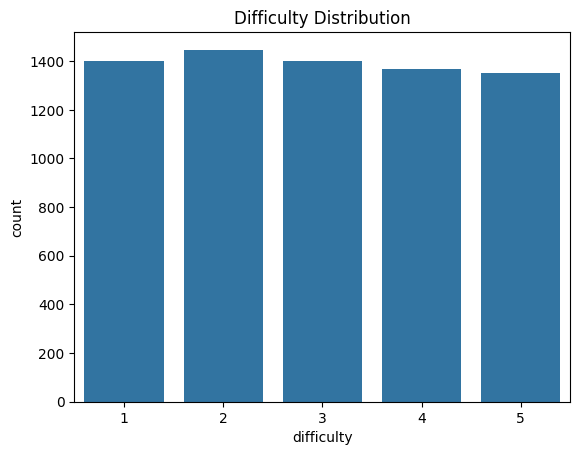

In [9]:
sns.countplot(x = "difficulty", data = df)
plt.title("Difficulty Distribution")
plt.show()

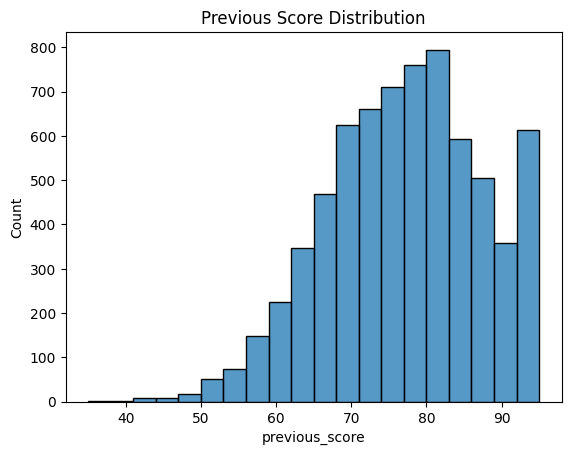

In [11]:
sns.histplot(df["previous_score"], bins=20)
plt.title("Previous Score Distribution")
plt.show()

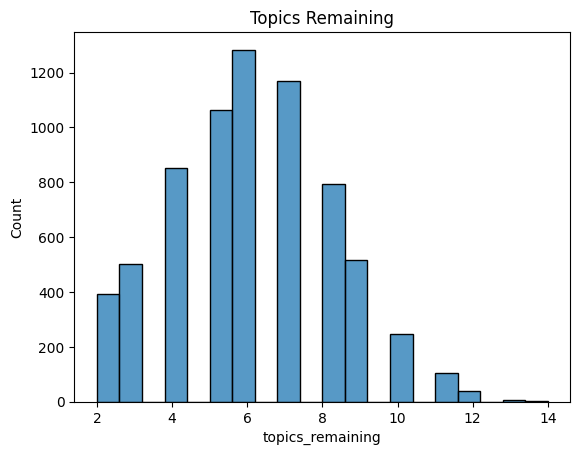

In [12]:
sns.histplot(df["topics_remaining"], bins=20)
plt.title("Topics Remaining")
plt.show()

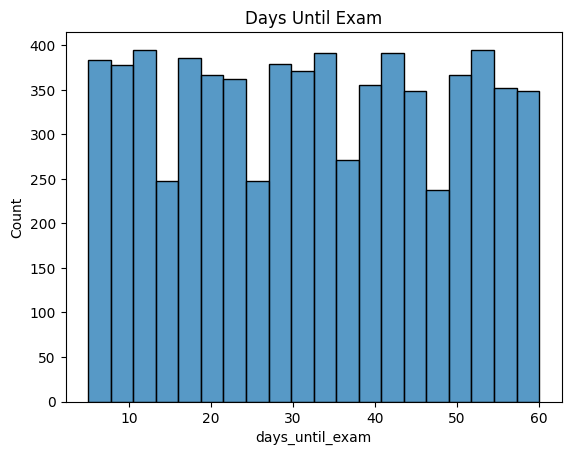

In [13]:
sns.histplot(df["days_until_exam"], bins=20)
plt.title("Days Until Exam")
plt.show()

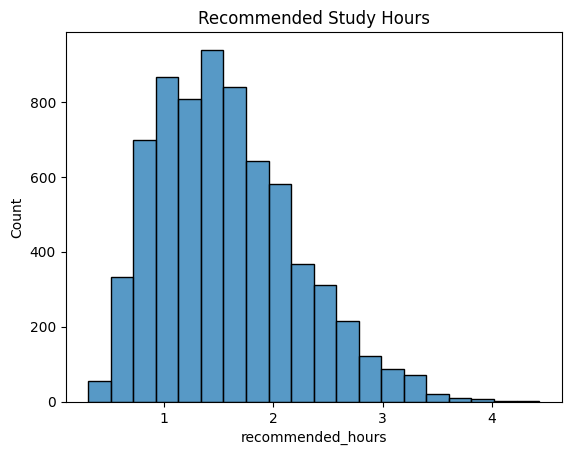

In [14]:
sns.histplot(df["recommended_hours"], bins=20)
plt.title("Recommended Study Hours")
plt.show()

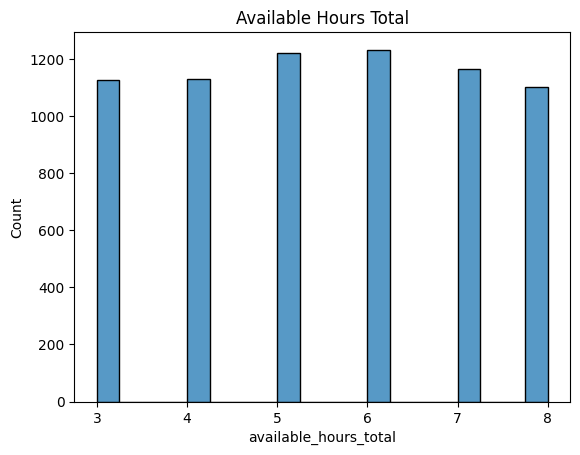

In [15]:
sns.histplot(df["available_hours_total"], bins=20)
plt.title("Available Hours Total")
plt.show()

## Feature Relationships

### Difficulty vs Study Hours

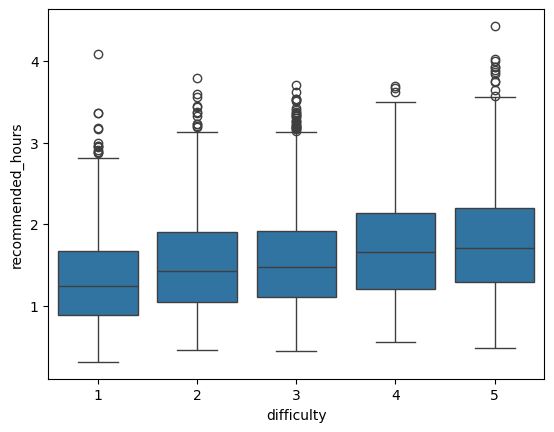

In [16]:
sns.boxplot(x="difficulty", y = "recommended_hours", data=df)
plt.show()

### Topics Remaining vs Study Hours

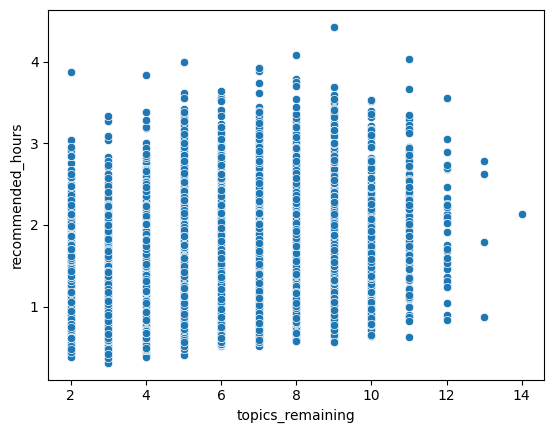

In [18]:
sns.scatterplot(
    x = "topics_remaining",
    y = "recommended_hours",
    data = df
)
plt.show()

### Previous Score vs Study Hours

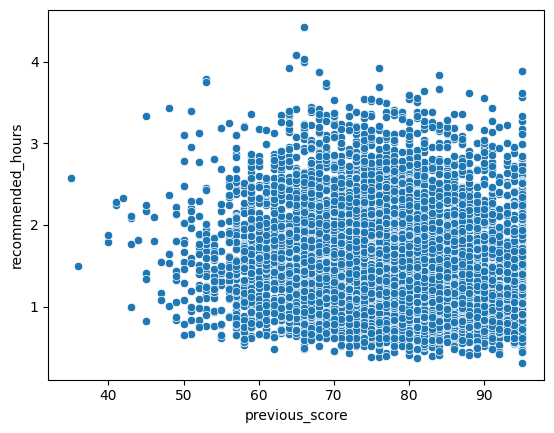

In [19]:
sns.scatterplot(
    x = "previous_score",
    y = "recommended_hours",
    data = df
)
plt.show()

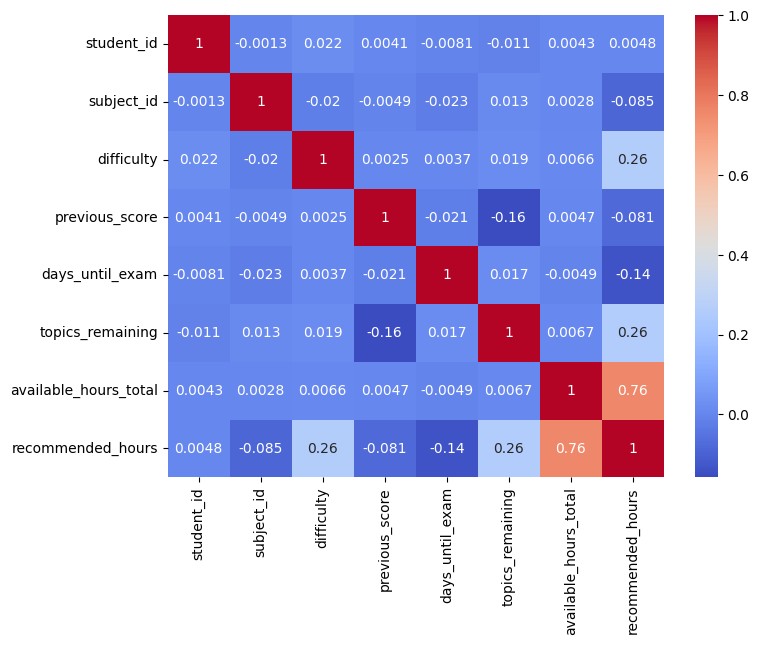

In [20]:
corr = df.corr(numeric_only = True)
plt.figure(figsize = (8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [21]:
df_processed = df.copy()
df_processed.to_csv(
    "../data/processed/processed_study_dataset.csv",
    index=False
)